# Keras Regression

##### EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Feature Columns
    
* id - Unique ID for each home sold
* date - Date of the home sale
* price - Price of each home sold
* bedrooms - Number of bedrooms
* bathrooms - Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* sqft_living - Square footage of the apartments interior living space
* sqft_lot - Square footage of the land space
* floors - Number of floors
* waterfront - A dummy variable for whether the apartment was overlooking the waterfront or not
* view - An index from 0 to 4 of how good the view of the property was
* condition - An index from 1 to 5 on the condition of the apartment,
* grade - An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design.
* sqft_above - The square footage of the interior housing space that is above ground level
* sqft_basement - The square footage of the interior housing space that is below ground level
* yr_built - The year the house was initially built
* yr_renovated - The year of the house’s last renovation
* zipcode - What zipcode area the house is in
* lat - Lattitude
* long - Longitude
* sqft_living15 - The square footage of interior housing living space for the nearest 15 neighbors
* sqft_lot15 - The square footage of the land lots of the nearest 15 neighbors

In [2]:
df = pd.read_csv('data/kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     21597 non-null  int64  
 9   view           21597 non-null  int64  
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21597 non-null  int64  
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   21597 non-null  int64  
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long  

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,21597.0,4.580474e+09,2.876736e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21597.0,5.402966e+05,3.673681e+05,7.800000e+04,3.220000e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21597.0,3.373200e+00,9.262989e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21597.0,2.115826e+00,7.689843e-01,5.000000e-01,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21597.0,2.080322e+03,9.181061e+02,3.700000e+02,1.430000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21597.0,1.509941e+04,4.141264e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068500e+04,1.651359e+06
floors,21597.0,1.494096e+00,5.396828e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21597.0,7.547345e-03,8.654900e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21597.0,2.342918e-01,7.663898e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21597.0,3.409825e+00,6.505456e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [5]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

<Axes: xlabel='price', ylabel='Count'>

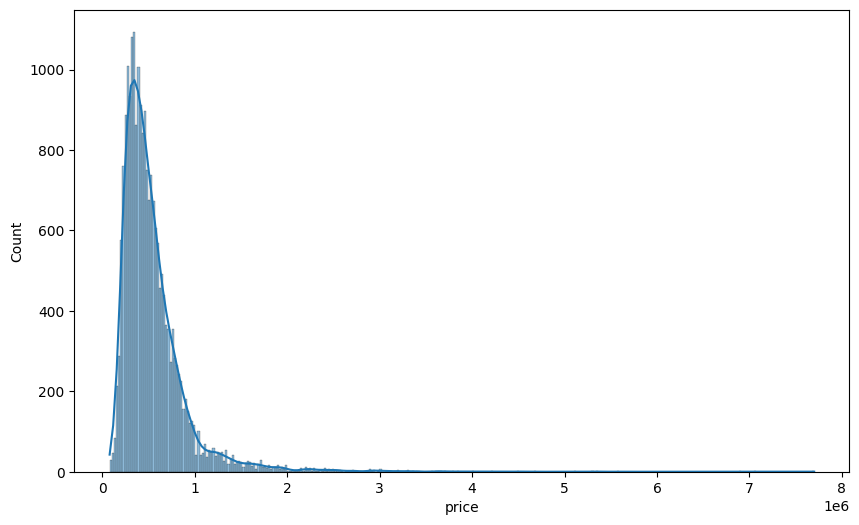

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True)

<Axes: xlabel='bedrooms', ylabel='count'>

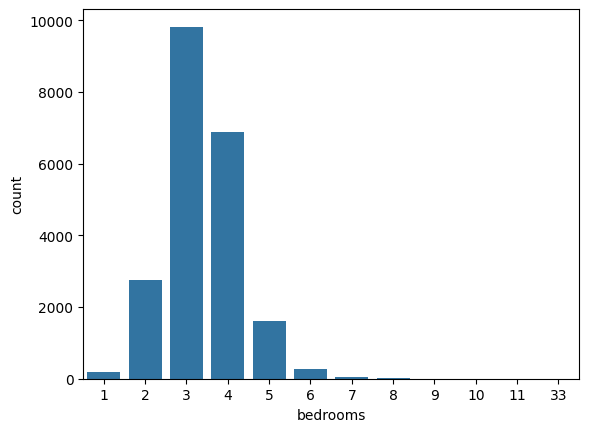

In [7]:
sns.countplot(data=df, x='bedrooms')

In [8]:
df.select_dtypes(include='number').corr()['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.701917
grade            0.667951
sqft_above       0.605368
sqft_living15    0.585241
bathrooms        0.525906
view             0.397370
sqft_basement    0.323799
bedrooms         0.308787
lat              0.306692
waterfront       0.266398
floors           0.256804
yr_renovated     0.126424
sqft_lot         0.089876
sqft_lot15       0.082845
yr_built         0.053953
condition        0.036056
long             0.022036
id              -0.016772
zipcode         -0.053402
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='sqft_living'>

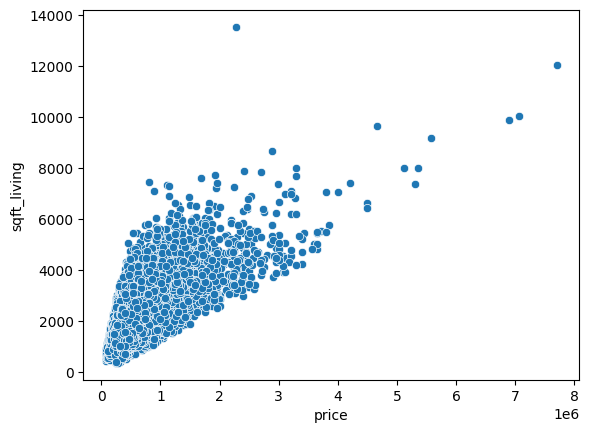

In [9]:
sns.scatterplot(x='price', y='sqft_living', data=df)

<Axes: xlabel='bedrooms', ylabel='price'>

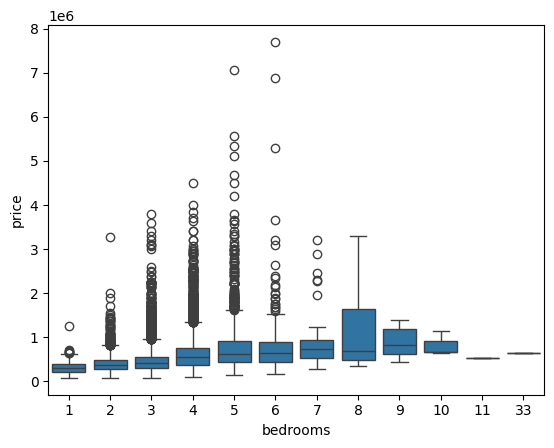

In [10]:
sns.boxplot(x='bedrooms', y='price', data=df)

<Axes: xlabel='price', ylabel='long'>

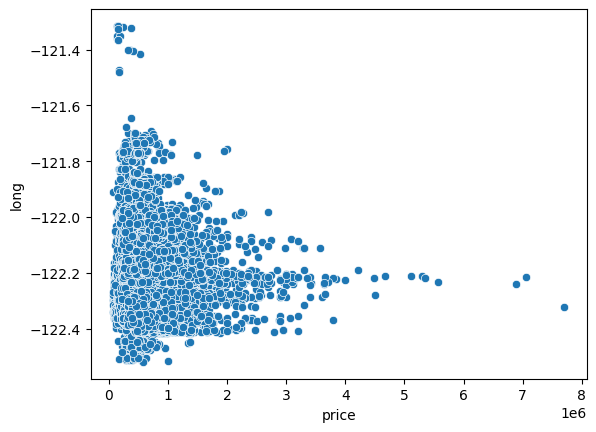

In [11]:
sns.scatterplot(x='price', y='long', data=df)

<Axes: xlabel='price', ylabel='lat'>

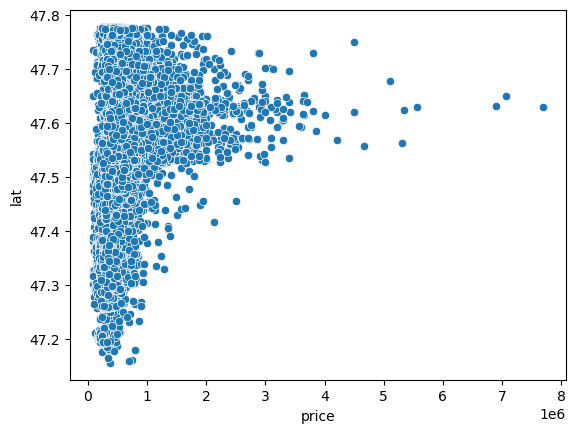

In [12]:
sns.scatterplot(x='price', y='lat', data=df)

<Axes: xlabel='long', ylabel='lat'>

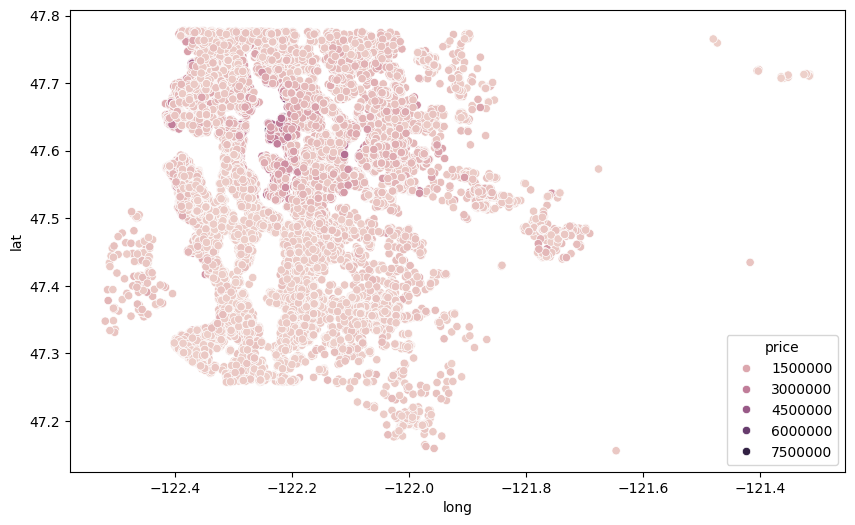

In [13]:
#Color gradient is not very helpful because of outliers, potentially remove them
plt.figure(figsize=(10,6))
sns.scatterplot(x='long', y='lat', data=df, hue='price')

In [14]:
df.sort_values(by='price', ascending=False).head(20)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
7245,6762700020,10/13/2014,7700000.0,6,8.00,12050,27600,2.5,0,3,...,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
3910,9808700762,6/11/2014,7060000.0,5,4.50,10040,37325,2.0,1,2,...,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
9245,9208900037,9/19/2014,6890000.0,6,7.75,9890,31374,2.0,0,4,...,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
4407,2470100110,8/4/2014,5570000.0,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
1446,8907500070,4/13/2015,5350000.0,5,5.00,8000,23985,2.0,0,4,...,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
1313,7558700030,4/13/2015,5300000.0,6,6.00,7390,24829,2.0,1,4,...,12,5000,2390,1991,0,98040,47.5631,-122.210,4320,24619
1162,1247600105,10/20/2014,5110000.0,5,5.25,8010,45517,2.0,1,4,...,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
8085,1924059029,6/17/2014,4670000.0,5,6.75,9640,13068,1.0,1,4,...,12,4820,4820,1983,2009,98040,47.5570,-122.210,3270,10454
2624,7738500731,8/15/2014,4500000.0,5,5.50,6640,40014,2.0,1,4,...,12,6350,290,2004,0,98155,47.7493,-122.280,3030,23408
8629,3835500195,6/18/2014,4490000.0,4,3.00,6430,27517,2.0,0,0,...,12,6430,0,2001,0,98004,47.6208,-122.219,3720,14592


In [15]:
len(df)*0.01

215.97

In [16]:
df2 = df.sort_values(by='price', ascending=False).iloc[216:]

<Axes: xlabel='long', ylabel='lat'>

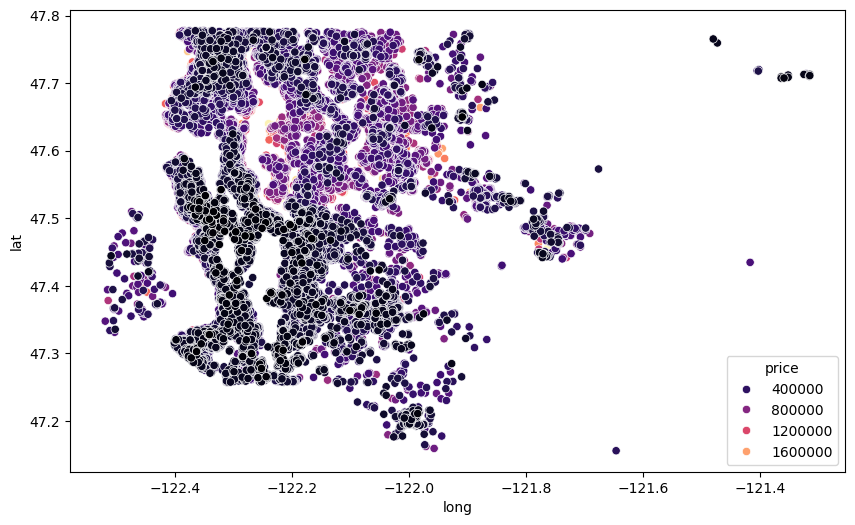

In [34]:
#Color gradient is not very helpful because of outliers, potentially remove them
plt.figure(figsize=(10,6))
sns.scatterplot(x='long', y='lat', data=df2, hue='price', palette='magma')

<Axes: xlabel='waterfront', ylabel='price'>

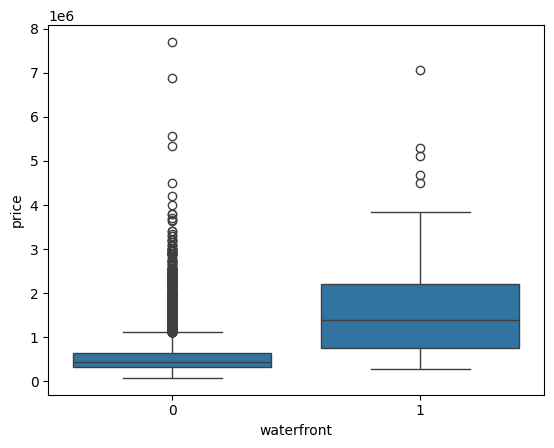

In [18]:
#Waterfront homes are on average more expensive
sns.boxplot(x='waterfront', y='price', data=df)

##### Feature Engineering & Removing Unnecessary Features

In [19]:
df2.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
6329,824059321,6/2/2014,1970000.0,4,3.50,4370,8510,2.0,0,1,...,10,3610,760,2003,0,98004,47.5876,-122.204,2960,10347
12271,1923000260,10/15/2014,1960000.0,5,4.50,6200,23373,3.0,0,1,...,11,5050,1150,1988,0,98040,47.5632,-122.215,3700,14486
9166,3124059023,2/13/2015,1960000.0,3,1.75,3330,12566,1.0,1,4,...,8,1940,1390,1960,0,98040,47.5287,-122.220,3730,16560
12565,2806300065,4/22/2015,1960000.0,4,4.00,4430,31353,2.0,0,0,...,12,4430,0,1998,0,98005,47.6422,-122.157,3900,35237
1150,4055701200,4/21/2015,1960000.0,4,2.75,3120,7898,1.0,1,4,...,8,1560,1560,1963,0,98034,47.7165,-122.259,2630,13868


In [20]:
#Id column has no inherent value. No trend to it, and nothing of immediate use for us, so we can drop it
df2.drop('id', axis=1)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
6329,6/2/2014,1970000.0,4,3.50,4370,8510,2.0,0,1,3,10,3610,760,2003,0,98004,47.5876,-122.204,2960,10347
12271,10/15/2014,1960000.0,5,4.50,6200,23373,3.0,0,1,4,11,5050,1150,1988,0,98040,47.5632,-122.215,3700,14486
9166,2/13/2015,1960000.0,3,1.75,3330,12566,1.0,1,4,4,8,1940,1390,1960,0,98040,47.5287,-122.220,3730,16560
12565,4/22/2015,1960000.0,4,4.00,4430,31353,2.0,0,0,3,12,4430,0,1998,0,98005,47.6422,-122.157,3900,35237
1150,4/21/2015,1960000.0,4,2.75,3120,7898,1.0,1,4,4,8,1560,1560,1963,0,98034,47.7165,-122.259,2630,13868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2139,5/8/2014,82500.0,2,1.00,520,22334,1.0,0,0,2,5,520,0,1951,0,98168,47.4799,-122.296,1572,10570
8267,11/5/2014,82000.0,3,1.00,860,10426,1.0,0,0,3,6,860,0,1954,0,98146,47.4987,-122.341,1140,11250
16184,3/24/2015,81000.0,2,1.00,730,9975,1.0,0,0,1,5,730,0,1943,0,98168,47.4808,-122.315,860,9000
465,5/23/2014,80000.0,1,0.75,430,5050,1.0,0,0,2,4,430,0,1912,0,98014,47.6499,-121.909,1200,7500


In [22]:
#Converting date to a datetime type since it is currently a string...format of values changed, as well as data type of column
df2['date'] = pd.to_datetime(df['date'])
df2['date']

6329    2014-06-02
12271   2014-10-15
9166    2015-02-13
12565   2015-04-22
1150    2015-04-21
           ...    
2139    2014-05-08
8267    2014-11-05
16184   2015-03-24
465     2014-05-23
15279   2014-05-06
Name: date, Length: 21381, dtype: datetime64[ns]

In [25]:
#Can use attribute call to grab values off of a DATETIME object
df2['year'] = df2['date'].apply(lambda date: date.year)
df2['month'] = df2['date'].apply(lambda date: date.month)

<Axes: xlabel='month', ylabel='price'>

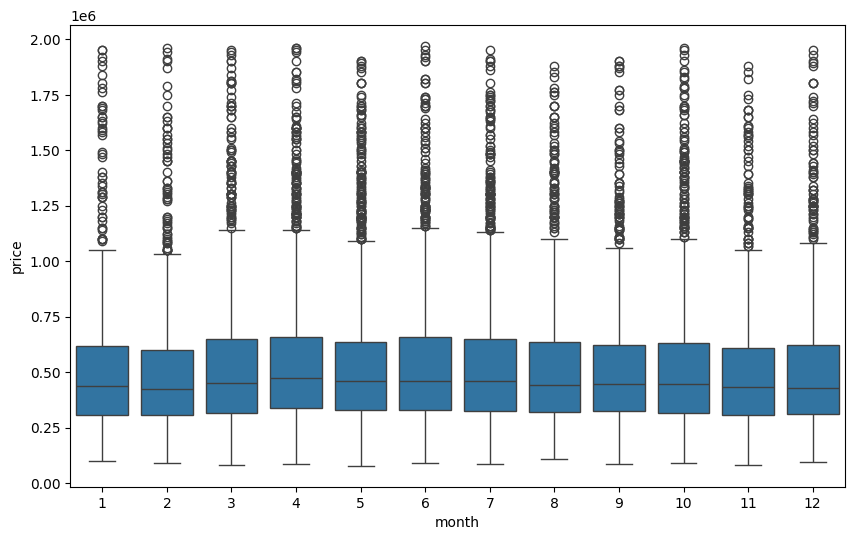

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(x='month', y='price', data=df2)

<Axes: xlabel='month'>

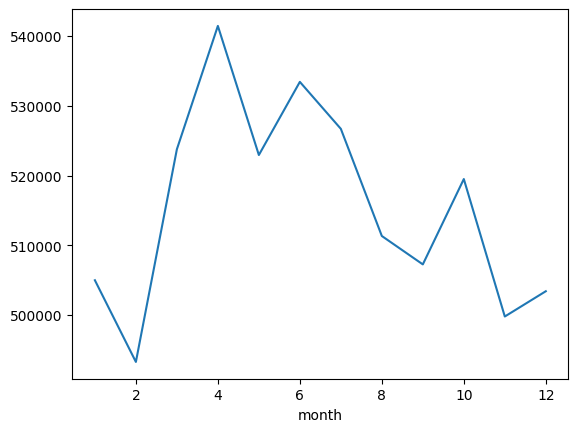

In [35]:
df2.groupby('month').mean()['price'].plot()

In [36]:
df2 = df2.drop('date', axis=1)

In [38]:
df2['zipcode'].value_counts()

zipcode
98103    602
98038    589
98115    582
98052    573
98117    553
        ... 
98010    100
98102     99
98024     80
98148     57
98039     29
Name: count, Length: 70, dtype: int64

In [39]:
#Dropping zipcode because too many values to create dummy variables for
df2 = df2.drop('zipcode', axis=1)

In [40]:
#0 is not a year, it is an indication to whether or not it was renovated
#Can look at this as 0 is houses not renovated, likely leading to a lower sale price, whereas remaining houses in recent years that are renovated
#Will likely have a higher sale price
df2['yr_renovated'].value_counts()

yr_renovated
0       20499
2014       91
2013       36
2000       34
2005       34
        ...  
1934        1
1954        1
1948        1
1959        1
1951        1
Name: count, Length: 70, dtype: int64

In [41]:
#Same story here as we saw for the yr_renovated column
df2['sqft_basement'].value_counts()

sqft_basement
0      13110
600      221
700      218
500      214
800      206
       ...  
518        1
374        1
784        1
906        1
248        1
Name: count, Length: 306, dtype: int64

##### Data Preprocessing and Creating Model

In [42]:
X = df2.drop('price', axis=1).values
y = df2['price'].values

In [43]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [46]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [47]:
#Can scale and fit in the same step with fit_transform, TRAINING SET ONLY
X_train = scaler.fit_transform(X_train)

In [48]:
#DO NOT FIT TO TEST, JUST TRANSFORM
X_test = scaler.transform(X_test)

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [50]:
X_train.shape

(14966, 20)

In [51]:
model = Sequential()

#Typically try to create as many layers as we have columns
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [53]:
#Training the model on training sets, but as we go along we are validating against our test sets to see if we are overfitting
model.fit(
    x=X_train, 
    y=y_train, 
    validation_data=(X_test, y_test),
    batch_size=128,
    epochs=400
)

Epoch 1/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 348870279168.0000 - val_loss: 356827267072.0000
Epoch 2/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 349295771648.0000 - val_loss: 352460341248.0000
Epoch 3/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 333205536768.0000 - val_loss: 314273333248.0000
Epoch 4/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 281915162624.0000 - val_loss: 193010614272.0000
Epoch 5/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 152230641664.0000 - val_loss: 72645623808.0000
Epoch 6/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 64561668096.0000 - val_loss: 57775714304.0000
Epoch 7/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 56041725952.0000 - val_loss: 56672641024.0000
Epoch 8/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 55664054272.0000 - val_loss: 55736913920.0000
Epoch 9/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54804787200.0000 - val_loss: 54714302464.0000
Epoch 10/400
117/117 ━━━━━━━

##### Model Evaluation and Predictions

In [57]:
#Adding in the validation check brings back the new val_loss column. It is the loss against our validation set.
losses = pd.DataFrame(model.history.history)
losses.head()

,loss,val_loss
0,3.468693e+11,3.568273e+11
1,3.456231e+11,3.524603e+11
2,3.289974e+11,3.142733e+11
3,2.534047e+11,1.930106e+11
4,1.195352e+11,7.264562e+10


<Axes: >

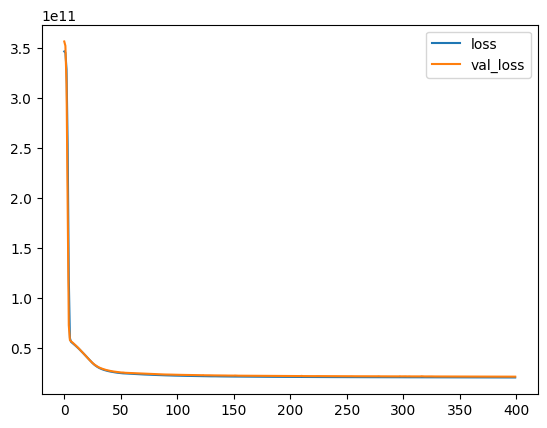

In [58]:
#Can compare the two against one another to see how the model is doing in regards to overfitting
losses.plot()

* Having both lines go down and continue going down is what we want.
* Because our val_loss is also going down, it's an indication we can continue training without overfitting to the training data
* If we saw the orange line begin to spike at some point, it would mean we are overfitting to the training data because we have a much larger loss on our validation data

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score

In [60]:
predictions = model.predict(X_test)

201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step


In [67]:
#Compare predictions to what we know are the correct values
meanAE = mean_absolute_error(y_test, predictions)
print(f"MAE: {meanAE}")
print(f"Our price predictions are off by about: {meanAE}")

MAE: 97611.86828234607
Our price predictions are off by about: 97611.86828234607


In [65]:
#This large value makes sense since we are dealing with the prices of houses
print(f"MSE: {mean_squared_error(y_test, predictions)}")

MSE: 21238267868.691296


In [66]:
print(f"RMSE: {mean_squared_error(y_test, predictions)**0.5}")

RMSE: 145733.5509369455


In [68]:
df2['price'].describe()

count    2.138100e+04
mean     5.183675e+05
std      2.849428e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.350000e+05
max      1.970000e+06
Name: price, dtype: float64

In [69]:
5.183675e+05

518367.5

* Comparing the MAE (97,611) vs the mean of the price column (518,367)
  * Given that the average home price is around `$500,000`, and our predictions are off by about `$98,000`, our model did not perform very well
  * Our predictions are off by about a fifth of our average home price, which is a large margin

In [73]:
#Best score is 1.0, tells us how much variance is being explained by our model
evs = round(explained_variance_score(y_test, predictions) * 100, 2)
print(f"Around {evs}% of the variance is being explained by our model")

Around 74.22% of the variance is being explained by our model


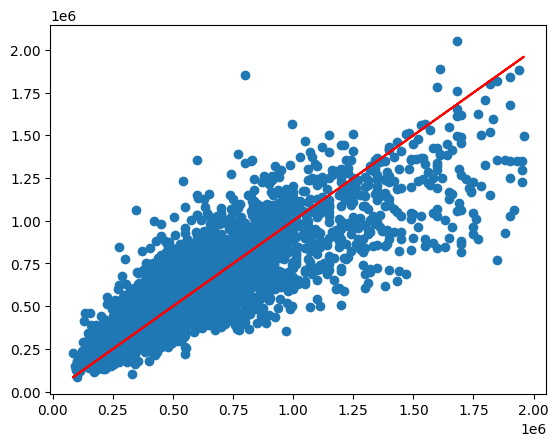

In [74]:
#Checking our test predictions against the actual values
plt.scatter(y_test, predictions)
plt.plot(y_test, y_test, 'r')

##### Testing on a "new" data point

In [75]:
#Grabbing first house as an example
single_house = df2.drop('price', axis=1).iloc[0]

In [79]:
#-1 basically says "keep the old dimensions along the axes", which is the double brackets, which is what we need
single_house = scaler.transform(single_house.values.reshape(-1, 20))

In [80]:
model.predict(single_house)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[1124217.1]], dtype=float32)

In [83]:
df2.iloc[0]

id               8.240593e+08
price            1.970000e+06
bedrooms         4.000000e+00
bathrooms        3.500000e+00
sqft_living      4.370000e+03
sqft_lot         8.510000e+03
floors           2.000000e+00
waterfront       0.000000e+00
view             1.000000e+00
condition        3.000000e+00
grade            1.000000e+01
sqft_above       3.610000e+03
sqft_basement    7.600000e+02
yr_built         2.003000e+03
yr_renovated     0.000000e+00
lat              4.758760e+01
long            -1.222040e+02
sqft_living15    2.960000e+03
sqft_lot15       1.034700e+04
year             2.014000e+03
month            6.000000e+00
Name: 6329, dtype: float64